<a href="https://colab.research.google.com/github/TusharSharmaji/16_TUSHARSHARMA_D2/blob/main/DL_Optimizer_Comparison_Full_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Optimizer Comparison
Random dataset (1-200), SGD vs RMSprop vs Adam, full comparison with graphs.

RANDOM DATASET
Sample 001 | X=[103. 180.  93.] | y=1119.81
Sample 002 | X=[ 15. 107.  72.] | y=645.78
Sample 003 | X=[189.  21. 103.] | y=854.40
Sample 004 | X=[122.  75.  88.] | y=811.27
Sample 005 | X=[117. 100. 104.] | y=958.39
Sample 006 | X=[152. 131. 150.] | y=1307.60
Sample 007 | X=[53.  2. 88.] | y=469.88
Sample 008 | X=[158.  38. 130.] | y=942.36
Sample 009 | X=[192. 188.  21.] | y=1025.99
Sample 010 | X=[161.  58.  22.] | y=574.96
Sample 011 | X=[89. 49. 59.] | y=567.16
Sample 012 | X=[170. 188.  15.] | y=974.15
Sample 013 | X=[190. 190. 175.] | y=1653.40
Sample 014 | X=[190.  51. 108.] | y=972.52
Sample 015 | X=[ 55.  64. 131.] | y=819.06
Sample 016 | X=[ 51. 135.  21.] | y=592.17
Sample 017 | X=[ 73. 167.  18.] | y=708.04
Sample 018 | X=[132.  89.  60.] | y=764.83
Sample 019 | X=[14.  9. 90.] | y=422.03
Sample 020 | X=[ 53. 130.  84.] | y=830.08
Sample 021 | X=[ 92. 111. 188.] | y=1278.68
Sample 022 | X=[199. 172.   8.] | y=950.30
Sample 023 | X=[175.  35.  81.] | y=800.88


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


\nPredictions
Sample 01 | Actual= 1201.54 | Predicted=-3888033.75
Sample 02 | Actual= 1283.06 | Predicted=-3888033.75
Sample 03 | Actual= 1001.68 | Predicted=-3888033.75
Sample 04 | Actual=  747.41 | Predicted=-3888033.75
Sample 05 | Actual= 1061.46 | Predicted=-3888033.75
Sample 06 | Actual=  245.74 | Predicted=-3888033.75
Sample 07 | Actual=  800.88 | Predicted=-3888033.75
Sample 08 | Actual= 1356.91 | Predicted=-3888033.75
Sample 09 | Actual=  567.16 | Predicted=-3888033.75
Sample 10 | Actual= 1119.81 | Predicted=-3888033.75
Sample 11 | Actual=  422.03 | Predicted=-3888033.75
Sample 12 | Actual=  769.01 | Predicted=-3888033.75
Sample 13 | Actual=  767.32 | Predicted=-3888033.75
Sample 14 | Actual=  545.22 | Predicted=-3888033.75
Sample 15 | Actual= 1442.33 | Predicted=-3888033.75
Sample 16 | Actual=  958.39 | Predicted=-3888033.75
Sample 17 | Actual= 1558.40 | Predicted=-3888033.75
Sample 18 | Actual= 1410.83 | Predicted=-3888033.75
Sample 19 | Actual= 1653.40 | Predicted=-3888033.7

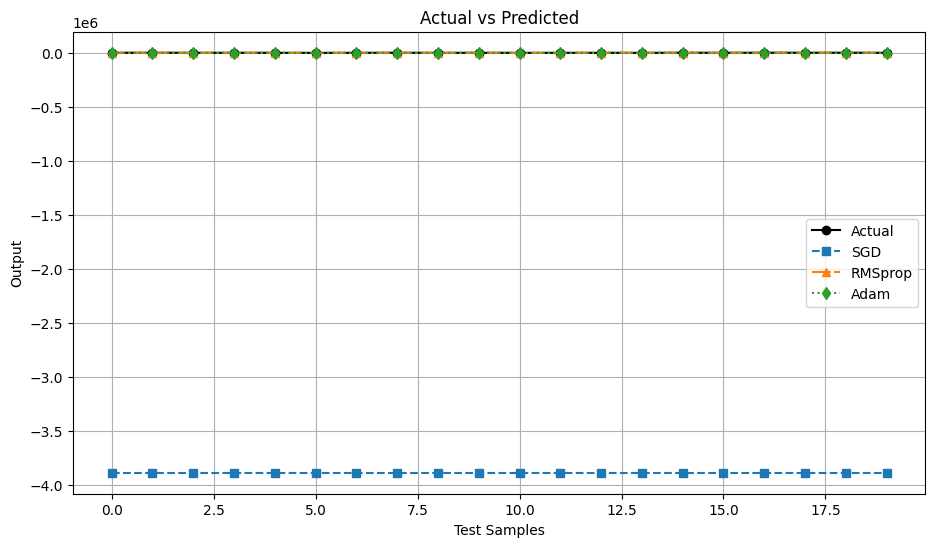

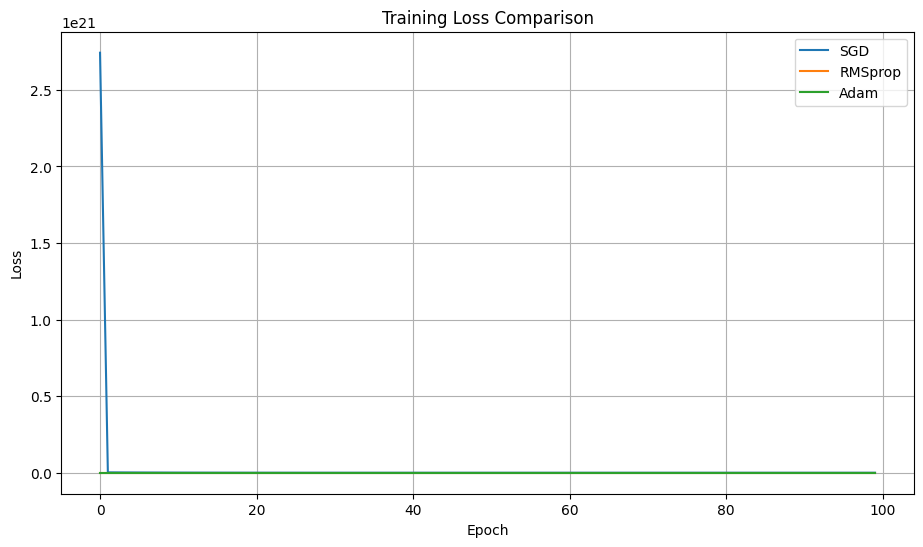

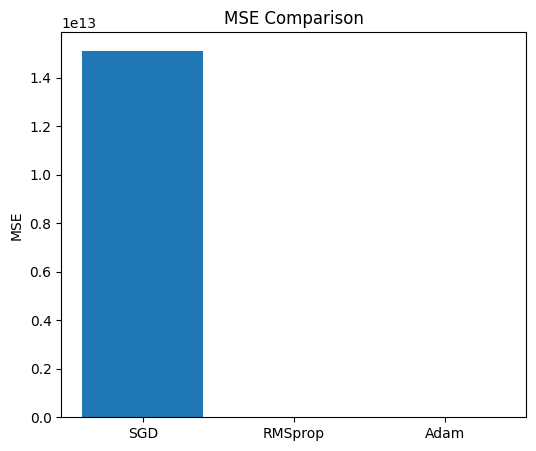

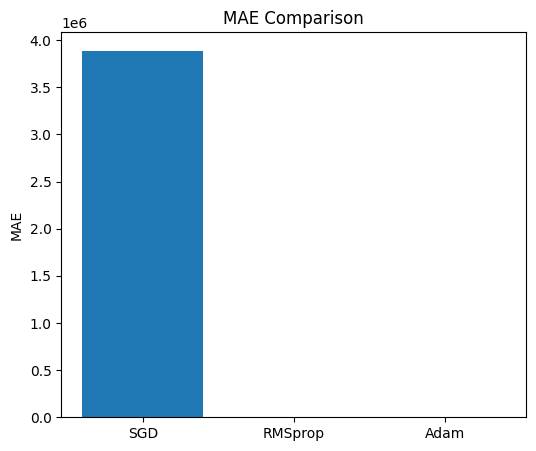

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

np.random.seed(42)

# ============================
# Generate Random Dataset
# ============================

X = np.random.randint(1, 201, size=(100,3)).astype(float)
noise = np.random.normal(0, 8, size=100)
y = 2*X[:,0] + 3*X[:,1] + 4*X[:,2] + noise

print("="*80)
print("RANDOM DATASET")
print("="*80)

for i in range(len(X)):
    print(f"Sample {i+1:03d} | X={X[i]} | y={y[i]:.2f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def build_model(opt):
    model = Sequential([
        Dense(16, activation="relu", input_shape=(3,)),
        Dense(8, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer=opt, loss="mse", metrics=["mae"])
    return model

optimizers = {
    "SGD": SGD(learning_rate=0.01),
    "RMSprop": RMSprop(learning_rate=0.001),
    "Adam": Adam(learning_rate=0.001)
}

results = {}
histories = {}

for name,opt in optimizers.items():

    print("\\n" + "="*70)
    print("Training using", name)
    print("="*70)

    model = build_model(opt)

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test,y_test),
        epochs=100,
        verbose=0
    )

    pred = model.predict(X_test, verbose=0).flatten()
    mse, mae = model.evaluate(X_test, y_test, verbose=0)

    histories[name] = history.history

    results[name] = {
        "prediction": pred,
        "mse": mse,
        "mae": mae
    }

    print("\\nPredictions")
    for i in range(len(y_test)):
        print(f"Sample {i+1:02d} | Actual={y_test[i]:8.2f} | Predicted={pred[i]:8.2f}")

print("\\n")
print("="*90)
print("FINAL COMPARISON")
print("="*90)
print(f"{'Sample':<8}{'Actual':<12}{'SGD':<12}{'RMSprop':<12}{'Adam':<12}")

for i in range(len(y_test)):
    print(
        f"{i+1:<8}"
        f"{y_test[i]:<12.2f}"
        f"{results['SGD']['prediction'][i]:<12.2f}"
        f"{results['RMSprop']['prediction'][i]:<12.2f}"
        f"{results['Adam']['prediction'][i]:<12.2f}"
    )

print("\\nOptimizer Performance")
for k,v in results.items():
    print(f"{k} -> MSE={v['mse']:.4f}  MAE={v['mae']:.4f}")

best=min(results.items(),key=lambda x:x[1]["mse"])
print("\\nBest Optimizer:",best[0])

plt.figure(figsize=(11,6))
plt.plot(y_test,'ko-',label='Actual')
plt.plot(results['SGD']['prediction'],'--s',label='SGD')
plt.plot(results['RMSprop']['prediction'],'-.^',label='RMSprop')
plt.plot(results['Adam']['prediction'],':d',label='Adam')
plt.title("Actual vs Predicted")
plt.xlabel("Test Samples")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(11,6))
for name in optimizers:
    plt.plot(histories[name]["loss"],label=name)
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
plt.bar(results.keys(),[results[k]["mse"] for k in results])
plt.title("MSE Comparison")
plt.ylabel("MSE")
plt.show()

plt.figure(figsize=(6,5))
plt.bar(results.keys(),[results[k]["mae"] for k in results])
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.show()
